# State Schema

## Review
In module 1, we laid the foundations. We built up to an agent that can:
- `act` - let the model call specific tools.
- `observe` - pass the tool output back to the model.
- `reason` - let the model reason about the tool output to decide what to do next.
- `persist state` - use an in memory checkpointer to support long-running conversations with interrupts.

## Goals
In this module, we're going to build a deeper understanding of both state and memory. First, let's review a few different ways to define your state schema.

## Schema
When we define a LangGraph `StateGraph`, we use a state schema. The state schema represents the structure and types of data that our graph will use.

All nodes are expected to communicate with that schema. LangGraph offers flexibility in how you define your state schema, accommodating various Python types and validation approaches.

## TypedDict
As we mentioned in Module 1, we can use the `TypedDict` class from python's `typing` module. It allows you to specify keys and their corresponding value types.

But, note that these are type hints. They can be used by static type checkers or IDEs to catch potential type-related errors before the code is run. But they are not enforced at runtime.

In [1]:
from typing_extensions import TypedDict
from typing import Literal

class TypedDictState(TypedDict):
    name: str
    mood: Literal["happy", "sad"]

We can use our defined state class (`TypedDictState`) in LangGraph by simply passing it to `StateGraph`. And, we can think about each state key as just a "channel" in our graph.

As discussed in Module 1, we overwrite the value of a specified key or "channel" in each node.

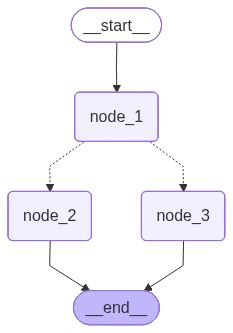

---Node 1---
---Node 2---


{'name': 'Lance is ...', 'mood': 'happy'}

In [4]:
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

def node_1(state):
    print("---Node 1---")
    return {"name": state["name"] + " is ..."}

def node_2(state):
    print("---Node 2---")
    return {"mood": "happy"}

def node_3(state):
    print("---Node 3---")
    return {"mood": "sad"}

def decide_mood(state) -> Literal["node_2", "node_3"]:
    if random.random() < 0.5:
        return "node_2"
    return "node_3"

# Build graph
builder = StateGraph(TypedDictState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({"name": "Lance"})

## Dataclass
Python's dataclasses provide another way to define structured data. Dataclasses offer a concise syntax for creating classes that are primarily used to store data.

To access the keys of a `dataclass`, we just need to modify the subscripting used in `node_1`:
    - We use `state.name` for the `dataclass` state rather than `state["name"]` for the `TypedDict` above.

You'll notice something a bit odd: in each node, we still return a dictionary to perform the state updates. This is possible because LangGraph stores each key of your state object separately. 

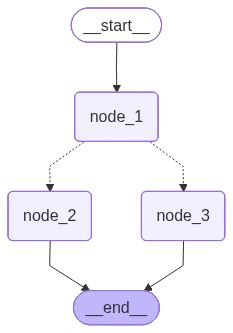

---Node 1---
---Node 2---


{'name': 'Lance is ...', 'mood': 'happy'}

In [5]:
from dataclasses import dataclass

@dataclass
class DataclassState:
    name: str
    mood: Literal["happy", "sad"]

def node_1(state):
    print("---Node 1---")
    return {"name": state.name + " is ..."}

# Build Graph
builder = StateGraph(DataclassState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke(DataclassState(name="Lance", mood="sad"))

## Pydantic
As mentioned, `TypedDict` and `dataclasses` provide type hints but they don't enforce type at runtime. This means you could potentially assign invalid values without raising an error.

Pydantic is a data validation and settings management library using Python type annotations. It's particularly well-suited for defining state schemas in LangGraph due to its validation capabilities.

Pydantic can perform validation to check whether data confirms to the specified types and constraints at runtime.

In [6]:
from pydantic import BaseModel, field_validator, ValidationError

class PydanticState(BaseModel):
    name: str
    mood: str

    @field_validator("mood")
    @classmethod
    def validate_mood(cls, value):
        if value not in ["happy", "sad"]:
            raise ValueError("Each mood must be either 'happy' or 'sad'.")
        return value

try:
    state = PydanticState(name="John Doe", mood="mad")
except ValidationError as e:
    print("Validation Error:", e)

Validation Error: 1 validation error for PydanticState
mood
  Value error, Each mood must be either 'happy' or 'sad'. [type=value_error, input_value='mad', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error


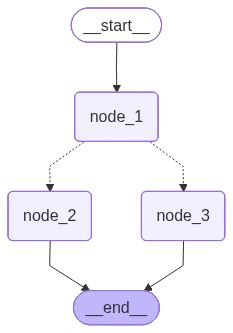

---Node 1---
---Node 3---


{'name': 'Lance is ...', 'mood': 'sad'}

In [7]:
# Build Graph
builder= StateGraph(PydanticState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)
graph = builder.compile()

# View 
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke(PydanticState(name="Lance", mood="sad"))